In [ ]:
!pip install ultralytics opencv-python matplotlib

In [ ]:
import string

import os
import xml.etree.ElementTree as ET

# 0-9, A-Z, a-z
labels = list(string.digits + string.ascii_uppercase + string.ascii_lowercase)
label_to_id = {label: idx for idx, label in enumerate(labels)}
id_to_label = {idx: label for idx, label in enumerate(labels)}

nc = len(labels)  # 62 classes

xml_folder = r'Enter Xml folder path'
txt_folder = r'Enter where you want to make lable text file'  # YOLO expects labels folder
os.makedirs(txt_folder, exist_ok=True)

def xml_to_yolo(xml_path, txt_path, label_to_id):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    size = root.find('size')
    img_width = int(size.find('width').text)
    img_height = int(size.find('height').text)

    yolo_lines = []

    for obj in root.findall('object'):
        name = obj.find('name').text.strip()
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        num_chars = len(name)
        char_width = (xmax - xmin) / num_chars

        for i, char in enumerate(name):
            if char not in label_to_id:
                continue
            class_id = label_to_id[char]

            char_xmin = xmin + i * char_width
            char_xmax = char_xmin + char_width

            # YOLO normalized coordinates
            x_center = (char_xmin + char_xmax) / 2 / img_width
            y_center = (ymin + ymax) / 2 / img_height
            w = (char_xmax - char_xmin) / img_width
            h = (ymax - ymin) / img_height

            yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

    with open(txt_path, 'w') as f:
        f.write('\n'.join(yolo_lines))

# Convert all XMLs
for xml_file in os.listdir(xml_folder):
    if xml_file.endswith('.xml'):
        xml_path = os.path.join(xml_folder, xml_file)
        txt_path = os.path.join(txt_folder, xml_file.replace('.xml', '.txt'))
        xml_to_yolo(xml_path, txt_path, label_to_id)

print("Conversion completed!")



In [ ]:
import os
import shutil
import random
import yaml

# Paths
images_folder = r'Enter image path'
labels_folder = r'enter generated txt filepath'   # your converted YOLO txt files
xml_folder = r'enter xml file path'
dataset_folder = r'enter path where you want to make dataset'

train_ratio = 0.8  # traing and testing data ration

# Create folders
for sub in ['images/train', 'images/val', 'labels/train', 'labels/val']:
    os.makedirs(os.path.join(dataset_folder, sub), exist_ok=True)

# Get all images
all_images = [f for f in os.listdir(images_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]
random.shuffle(all_images)

split_idx = int(len(all_images) * train_ratio)
train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

def copy_files(file_list, img_dest, lbl_dest):
    for img_file in file_list:
        try:
            lbl_file = os.path.splitext(img_file)[0] + '.txt'
            # Copy image
            shutil.copy(os.path.join(images_folder, img_file), os.path.join(dataset_folder, img_dest, img_file))
            # Copy corresponding label
            shutil.copy(os.path.join(labels_folder, lbl_file), os.path.join(dataset_folder, lbl_dest, lbl_file))
        except Exception as e:
            print(img_file,e)

# Copy train and val files
copy_files(train_images, 'images/train', 'labels/train')
copy_files(val_images, 'images/val', 'labels/val')

print("Files organized into train/val successfully!")

data_yaml = {
    'train': os.path.join(dataset_folder, 'images/train'),
    'val': os.path.join(dataset_folder, 'images/val'),
    'nc': nc,  # number of classes
    'names': labels
}

yaml_file = os.path.join(dataset_folder, 'data.yaml')
with open(yaml_file, 'w') as f:
    yaml.dump(data_yaml, f)



In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(data='data.yaml',
            epochs = 100,
            imgsz=640,
            batch=20,
            device='mps')

In [ ]:
%matplotlib inline
import pandas as pd 
import matplotlib.pyplot as plt
df = pd.read_csv(r'runs/detect/train/results.csv')
plt.figure(figsize=(10,5))
plt.plot(df['epoch'],df['train/box_loss'],label = 'Box Loss')
plt.plot(df['epoch'],df['train/cls_loss'],label = 'CLS Loss')
plt.plot(df['epoch'],df['train/dfl_loss'], label='DFL loss')
plt.plot(df['epoch'],df['metrics/mAP50(B)'], label = 'mAP50')
plt.xlabel('Epoch')
plt.ylabel('LOSS / mAP')
plt.legend()
plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train/weights/best.pt')
results = model.predict('dataset/images/val/38.png',save=True)


det_chara = []
for box in  results[0].boxes:
    class_id = int(box.cls[0])
    char = labels[class_id]
    print(char,box.xyxy[0])

In [ ]:
from ultralytics import YOLO


model = YOLO('runs/detect/scania_model_train_v1_google_collab/weights/best.pt')

results = model.predict(r'../scania_images/scania_images/B304117.png',save=True,conf=0.3,iou=0.1)




chars_list = []
for box in  results[0].boxes:
    class_id = int(box.cls[0])
    char = labels[class_id]
    x1,y1,x2,y2 = box.xyxy[0].tolist()
    x_center = ((x1+x2)/2)
    y_center = ((y1+y2)/2)
    print(char,box.xyxy[0],x_center,y_center)
    chars_list.append({ "char":char,"x_center": x_center,"y_center": y_center, "xyxy": (x1,y1,x2,y2)})


# Step 2: sort by y_center first (top to bottom), then x_center (left to right)
chars_list.sort(key=lambda x: x['y_center'])

# Step 2: convert y_center to int
for c in chars_list:
    c['y_center_int'] = int(c['y_center'])

# Step 3: sort by integer y_center and x_center ascending
chars_list.sort(key=lambda x: (x['y_center_int'], x['x_center']))

print("after sort")
for c in chars_list:
    print(c["char"],c["xyxy"],c["x_center"],c["y_center"])
# Step 3: group characters
x_threshold = 20  # adjust based on spacing in your image
y_threshold = 0.5   # adjust based on vertical alignment

groups = []
while chars_list:
    current_group = [chars_list.pop(0)]
    
    i = 0
    while i < len(chars_list):
        candidate = chars_list[i]
        y_diff = int(abs(candidate['y_center'] - current_group[0]['y_center']))
        x_diff = int(abs(candidate['x_center'] - current_group[-1]['x_center']))
        
        if y_diff <= y_threshold and x_diff <= x_threshold:
            current_group.append(candidate)
            chars_list.pop(i)
        else:
            i += 1
    
    groups.append(current_group)

# Step 4: merge characters and compute combined xyxy
combined_results = []
for group in groups:
    group.sort(key=lambda x: x['x_center'])  # sort left-to-right
    combined_char = ''.join([c['char'] for c in group])
    
    x1 = min(c['xyxy'][0] for c in group)
    y1 = min(c['xyxy'][1] for c in group)
    x2 = max(c['xyxy'][2] for c in group)
    y2 = max(c['xyxy'][3] for c in group)
    
    combined_results.append({
        'chars': combined_char,
        'xyxy': (x1, y1, x2, y2),
        'x_center': (x1 + x2)/2,
        'y_center': (y1 + y2)/2
    })

# Step 5: print
for item in combined_results:
    print(f"Chars: {item['chars']}, xyxy: {item['xyxy']}, x_center: {item['x_center']:.2f}, y_center: {item['y_center']:.2f}")


image 1/1 E:\scania_images\scania_images\B304117.png: 960x704 1 1, 1 2, 603.1ms
Speed: 9.3ms preprocess, 603.1ms inference, 1.5ms postprocess per image at shape (1, 3, 960, 704)
Results saved to E:\ADAP_Sharing\runs\detect\predict24
2 tensor([ 477.8764, 1023.3594,  498.1759, 1047.6177]) 488.0261535644531 1035.4885559082031
1 tensor([675.1783, 802.6960, 692.7864, 827.4416]) 683.9823608398438 815.0688171386719
after sort
1 (675.1782836914062, 802.696044921875, 692.7864379882812, 827.4415893554688) 683.9823608398438 815.0688171386719
2 (477.87640380859375, 1023.3594360351562, 498.1759033203125, 1047.61767578125) 488.0261535644531 1035.4885559082031
Chars: 1, xyxy: (675.1782836914062, 802.696044921875, 692.7864379882812, 827.4415893554688), x_center: 683.98, y_center: 815.07
Chars: 2, xyxy: (477.87640380859375, 1023.3594360351562, 498.1759033203125, 1047.61767578125), x_center: 488.03, y_center: 1035.49


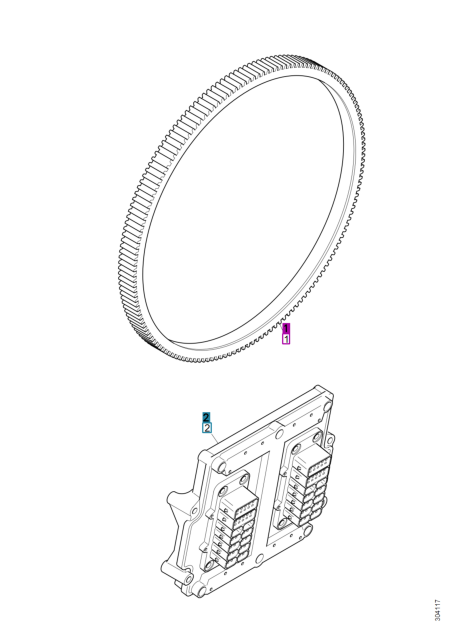

In [ ]:
import cv2
import random
import matplotlib.pyplot as plt

# Load image
img = cv2.imread(r'.\scania_images\scania_images\B106987.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB

# Draw bounding boxes and labels
for item in combined_results:
    x1, y1, x2, y2 = map(int, item['xyxy'])
    text = item['chars']

    # Random color for each label
    color = [random.randint(0, 255) for _ in range(3)]

    # Draw rectangle
    cv2.rectangle(img, (x1, y1), (x2, y2), color=color, thickness=2)

    # Text background
    (text_width, text_height), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
    y_text = max(y1, text_height + 10)  # Ensure text is visible inside image
    cv2.rectangle(img, (x1, y_text - text_height - baseline), (x1 + text_width, y_text), color, -1)

    # Put label text (black text on colored background)
    cv2.putText(img, text, (x1, y_text - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

# Show image
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
import os
import cv2
import xml.etree.ElementTree as ET
from ultralytics import YOLO
import string
from xml.dom import minidom
from tqdm import tqdm

# -----------------------------
# CONFIG
# -----------------------------

model_path = "runs/detect/scania_model_train_v1_google_collab/weights/best.pt"




images_path = r".\scania_images\scania_images"
output_xml_dir = r".\scania_images\scania_images"
os.makedirs(output_xml_dir, exist_ok=True)

def enhance_digits(img_path):
    img = cv2.imread(img_path)

    # Convert to gray
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Adaptive threshold (creates pure black digits on white bg)
    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        15, 3
    )

    # Blend with original to keep natural look but dark digits
    blended = cv2.addWeighted(gray, 0.7, thresh, 0.3, 0)

    # Ensure background stays pure white
    final = cv2.threshold(blended, 200, 255, cv2.THRESH_BINARY)[1]

    # Convert for YOLO
    final = cv2.cvtColor(final, cv2.COLOR_GRAY2BGR) 
    return final 



labels = list(string.digits + string.ascii_uppercase + string.ascii_lowercase )

x_threshold = 17  # max horizontal gap to group
y_threshold = 0.5  # max vertical difference to group

# -----------------------------
# LOAD MODEL
# -----------------------------
model = YOLO(model_path)

# -----------------------------
# FUNCTION TO GROUP CHARACTERS
# -----------------------------
def group_chars(chars_list):
    chars_list.sort(key=lambda x: x['y_center'])

    # Step 2: convert y_center to int
    for c in chars_list:
        c['y_center_int'] = int(c['y_center'])

    # Step 3: sort by integer y_center and x_center ascending
    chars_list.sort(key=lambda x: (x['y_center_int'], x['x_center']))

    groups = []
    while chars_list:
        current_group = [chars_list.pop(0)]
        
        i = 0
        while i < len(chars_list):
            candidate = chars_list[i]
            y_diff = int(abs(candidate['y_center'] - current_group[0]['y_center']))
            x_diff = int(abs(candidate['x_center'] - current_group[-1]['x_center']))
            
            if y_diff <= y_threshold and x_diff <= x_threshold:
                current_group.append(candidate)
                chars_list.pop(i)
            else:
                i += 1
        
        groups.append(current_group)

    # Step 4: merge characters and compute combined xyxy
    combined_results = []
    for group in groups:
        group.sort(key=lambda x: x['x_center'])  # sort left-to-right
        combined_char = ''.join([c['char'] for c in group])
        
        x1 = min(c['xyxy'][0] for c in group)
        y1 = min(c['xyxy'][1] for c in group)
        x2 = max(c['xyxy'][2] for c in group)
        y2 = max(c['xyxy'][3] for c in group)
        
        combined_results.append({
            'chars': combined_char,
            'xyxy': (x1, y1, x2, y2),
            'x_center': (x1 + x2)/2,
            'y_center': (y1 + y2)/2
        })
        
    return combined_results
    
# -----------------------------
# FUNCTION TO CREATE XML
# -----------------------------

def create_xml(image_path, detections):
    img = cv2.imread(image_path)
    height, width, depth = img.shape
    annotation = ET.Element("annotation")

    folder = ET.SubElement(annotation, "folder")
    folder.text = os.path.basename(os.path.dirname(image_path))

    filename = ET.SubElement(annotation, "filename")
    filename.text = os.path.basename(image_path)

    path = ET.SubElement(annotation, "path")
    path.text = image_path

    source = ET.SubElement(annotation, "source")
    database = ET.SubElement(source, "database")
    database.text = "Unknown"

    size = ET.SubElement(annotation, "size")
    w = ET.SubElement(size, "width")
    w.text = str(width)
    h = ET.SubElement(size, "height")
    h.text = str(height)
    d = ET.SubElement(size, "depth")
    d.text = str(depth)

    seg = ET.SubElement(annotation, "segmented")
    seg.text = "0"

    # Add each detection as <object>
    for det in detections:
        obj = ET.SubElement(annotation, "object")

        name = ET.SubElement(obj, "name")
        name.text = det["chars"]

        pose = ET.SubElement(obj, "pose")
        pose.text = "Unspecified"

        truncated = ET.SubElement(obj, "truncated")
        truncated.text = "0"

        difficult = ET.SubElement(obj, "difficult")
        difficult.text = "0"

        bndbox = ET.SubElement(obj, "bndbox")
        xmin = ET.SubElement(bndbox, "xmin")
        xmin.text = str(int(det["xyxy"][0]))
        ymin = ET.SubElement(bndbox, "ymin")
        ymin.text = str(int(det["xyxy"][1]))
        xmax = ET.SubElement(bndbox, "xmax")
        xmax.text = str(int(det["xyxy"][2]))
        ymax = ET.SubElement(bndbox, "ymax")
        ymax.text = str(int(det["xyxy"][3]))

    xml_str = minidom.parseString(ET.tostring(annotation)).toprettyxml(indent="\t")
    xml_output_path = os.path.join(
        output_xml_dir, os.path.splitext(os.path.basename(image_path))[0] + ".xml"
    )

    with open(xml_output_path, "w", encoding="utf-8") as f:
        f.write(xml_str)
    
# -----------------------------
# PROCESS ALL IMAGES
# -----------------------------
files = [f for f in os.listdir(images_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]

for img_file in tqdm(files, desc= "Hotspot Detection and XML File Generation: "):
    img_path = os.path.join(images_path, img_file)
    

    # img = enhance_digits(img_path)
    img = img_path
    
    # YOLO prediction
    # results = model.predict(img,conf = 0.3,iou=0.1, verbose=False)
    results = model.predict(img,iou=0.1, verbose=False)
    
    
    chars_list = []
    for box in  results[0].boxes:
        class_id = int(box.cls[0])
        char = labels[class_id]
        x1,y1,x2,y2 = box.xyxy[0].tolist()
        x_center = ((x1+x2)/2)
        y_center = ((y1+y2)/2)
        chars_list.append({ "char":char,"x_center": x_center,"y_center": y_center, "xyxy": (x1,y1,x2,y2)})
        
    # Group characters
    combined_boxes = group_chars(chars_list)
    
    # Create XML
    create_xml(img_path, combined_boxes)

print("All XML files generated successfully!")

Hotspot Detection and XML File Generation: 100%|██████████| 80856/80856 [13:15:40<00:00,  1.69it/s]  

All XML files generated successfully!


In [ ]:
import os
import cv2
import xml.etree.ElementTree as ET
from ultralytics import YOLO
import string
from xml.dom import minidom
from tqdm import tqdm

# -----------------------------
# CONFIG
# -----------------------------
model_path = "runs/detect/resize_model_best8/weights/best.pt"

images_path = r".\scania_images\New Images\img_png"
output_xml_dir = r".\scania_images\New Images\img_png"
os.makedirs(output_xml_dir, exist_ok=True)

labels = list(string.digits + string.ascii_uppercase + string.ascii_lowercase)

# -----------------------------
# LOAD MODEL
# -----------------------------
model = YOLO(model_path)

# -----------------------------
# NEW GROUPING LOGIC (xyxy-based)
# -----------------------------
def should_group_digits(box1, box2, threshold_ratio=0.5):
    """
    box format: (x1, y1, x2, y2)
    """
    # Horizontal gap
    gap = box2[0] - box1[2]   # left2 - right1
    
    # widths
    width1 = box1[2] - box1[0]
    width2 = box2[2] - box2[0]
    avg_width = (width1 + width2) / 2

    # vertical alignment
    center_y1 = (box1[1] + box1[3]) / 2
    center_y2 = (box2[1] + box2[3]) / 2
    vertical_diff = abs(center_y1 - center_y2)

    max_height = max(box1[3] - box1[1], box2[3] - box2[1])

    # grouping rule
    return (gap < threshold_ratio * avg_width) and (vertical_diff < 0.5 * max_height)


# -----------------------------
# FUNCTION TO GROUP CHARACTERS USING NEW LOGIC
# -----------------------------
def group_chars(chars_list):

    # Sort by y then x
    chars_list.sort(key=lambda x: (int(x['y_center']), x['x_center']))

    groups = []
    used = set()

    for i in range(len(chars_list)):
        if i in used:
            continue

        base = chars_list[i]
        base_box = base["xyxy"]

        group = [base]
        used.add(i)

        for j in range(i+1, len(chars_list)):
            if j in used:
                continue

            cand = chars_list[j]
            cand_box = cand["xyxy"]

            # Apply new grouping logic
            if should_group_digits(base_box, cand_box):
                group.append(cand)
                used.add(j)
                base_box = cand_box  # update previous box

        groups.append(group)

    # Merge bounding boxes & characters
    combined = []
    for g in groups:
        g.sort(key=lambda x: x["x_center"])  # left-to-right

        chars = ''.join([c['char'] for c in g])

        x1 = min(c['xyxy'][0] for c in g)
        y1 = min(c['xyxy'][1] for c in g)
        x2 = max(c['xyxy'][2] for c in g)
        y2 = max(c['xyxy'][3] for c in g)

        combined.append({
            'chars': chars,
            'xyxy': (x1, y1, x2, y2),
            'x_center': (x1 + x2) / 2,
            'y_center': (y1 + y2) / 2
        })

    return combined


# -----------------------------
# FUNCTION TO CREATE XML
# -----------------------------
def create_xml(image_path, detections):
    img = cv2.imread(image_path)
    height, width, depth = img.shape
    annotation = ET.Element("annotation")

    folder = ET.SubElement(annotation, "folder")
    folder.text = os.path.basename(os.path.dirname(image_path))

    filename = ET.SubElement(annotation, "filename")
    filename.text = os.path.basename(image_path)

    path = ET.SubElement(annotation, "path")
    path.text = image_path

    source = ET.SubElement(annotation, "source")
    database = ET.SubElement(source, "database")
    database.text = "Unknown"

    size = ET.SubElement(annotation, "size")
    w = ET.SubElement(size, "width")
    w.text = str(width)
    h = ET.SubElement(size, "height")
    h.text = str(height)
    d = ET.SubElement(size, "depth")
    d.text = str(depth)

    seg = ET.SubElement(annotation, "segmented")
    seg.text = "0"

    # Add objects
    for det in detections:
        obj = ET.SubElement(annotation, "object")

        name = ET.SubElement(obj, "name")
        name.text = det["chars"]

        pose = ET.SubElement(obj, "pose")
        pose.text = "Unspecified"

        truncated = ET.SubElement(obj, "truncated")
        truncated.text = "0"

        difficult = ET.SubElement(obj, "difficult")
        difficult.text = "0"

        bndbox = ET.SubElement(obj, "bndbox")
        xmin = ET.SubElement(bndbox, "xmin")
        xmin.text = str(int(det["xyxy"][0]))
        ymin = ET.SubElement(bndbox, "ymin")
        ymin.text = str(int(det["xyxy"][1]))
        xmax = ET.SubElement(bndbox, "xmax")
        xmax.text = str(int(det["xyxy"][2]))
        ymax = ET.SubElement(bndbox, "ymax")
        ymax.text = str(int(det["xyxy"][3]))

    xml_str = minidom.parseString(ET.tostring(annotation)).toprettyxml(indent="\t")
    xml_output_path = os.path.join(output_xml_dir,
                                   os.path.splitext(os.path.basename(image_path))[0] + ".xml")

    with open(xml_output_path, "w", encoding="utf-8") as f:
        f.write(xml_str)


# -----------------------------
# PROCESS ALL IMAGES
# -----------------------------
files = [f for f in os.listdir(images_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
for img_file in tqdm(files, desc="Hotspot Detection and XML File Generation:"):
    img_path = os.path.join(images_path, img_file)

    # YOLO prediction
    results = model.predict(source=img_path,conf=0.3,iou=0.1, verbose=False)

    chars_list = []
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        char = labels[class_id]

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2

        chars_list.append({
            "char": char,
            "x_center": x_center,
            "y_center": y_center,
            "xyxy": (x1, y1, x2, y2)
        })

    # New grouping
    combined_boxes = group_chars(chars_list)

    # Create XML
    create_xml(img_path, combined_boxes)

print("All XML files generated successfully!")


Hotspot Detection and XML File Generation::  68%|██████▊   | 25352/37235 [1:00:49<28:30,  6.95it/s]


KeyboardInterrupt: 